<a href="https://colab.research.google.com/github/jameskrice7/jameskrice7/blob/main/MFormer_uselection_mueller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [19]:
from google.colab import files
uploaded = files.upload()


Saving processed-data_2016uselection.csv to processed-data_2016uselection.csv


In [24]:
import pandas as pd

df = pd.read_csv("processed-data_2016uselection.csv", encoding="latin")

# Check the actual column names in your DataFrame
print(df.columns)

# Assuming the correct column name is 'body' based on Global Variables, replace 'text' with 'body'
texts = df['clean_text'].fillna("").tolist()  # Handle any missing values just in case

Index(['corpus', 'clean_text', 'diffusion', 'followers', 'verified', 'media',
       'urls', 'hashtags', 'ME', 'moral', 'emo', 'XYZcount', 'n_char'],
      dtype='object')


In [25]:
print(df.head())

           corpus                                         clean_text  \
0  2016USElection            you should be president for saying that   
1  2016USElection  i literally pose half naked for a living and u...   
2  2016USElection                               you are full of shit   
3  2016USElection                             youre fucking retarded   
4  2016USElection          you are the stupidest man on planet earth   

   diffusion  followers  verified  media  urls  hashtags  ME  moral  emo  \
0       1210        804         0      0     0         0   0      1    0   
1       1656    3983853         1      0     0         0   1      0    0   
2       4688      29163         1      0     0         0   0      0    1   
3      10418        397         0      0     0         0   0      0    1   
4       1930       1350         0      0     0         0   0      0    1   

   XYZcount  n_char  
0         0      56  
1         3     140  
2         1      38  
3         1      40  


In [26]:
!pip install transformers

In [28]:
from transformers import pipeline
import pandas as pd
from tqdm import tqdm

# Your cleaned text input
texts = df['clean_text'].fillna("").tolist()

# Moral foundations and associated models
foundation_models = {
    "care": "joshnguyen/mformer-care",
    "fairness": "joshnguyen/mformer-fairness",
    "loyalty": "joshnguyen/mformer-loyalty",
    "authority": "joshnguyen/mformer-authority",
    "purity": "joshnguyen/mformer-sanctity"
}

# DataFrame to collect all predictions
preds_df = pd.DataFrame()

# Run each model separately
for foundation, model_name in foundation_models.items():
    print(f"Running model for: {foundation}")

    classifier = pipeline("text-classification", model=model_name, device=0 if torch.cuda.is_available() else -1)

    foundation_preds = []

    batch_size = 8
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]
        batch = [str(item) if not isinstance(item, str) else item for item in batch]

        results = classifier(batch)

        # Extract the score for the positive class
        scores = [r['score'] if r['label'] == 'LABEL_1' else 1 - r['score'] for r in results]
        foundation_preds.extend(scores)

    preds_df[foundation] = foundation_preds

# Merge predictions back into original DataFrame
df_out = pd.concat([df.reset_index(drop=True), preds_df.reset_index(drop=True)], axis=1)


Running model for: care


config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cuda:0

100%|██████████| 1004/1004 [01:09<00:00, 14.36it/s]


In [31]:
print(df_out.head())

           corpus                                         clean_text  \
0  2016USElection            you should be president for saying that   
1  2016USElection  i literally pose half naked for a living and u...   
2  2016USElection                               you are full of shit   
3  2016USElection                             youre fucking retarded   
4  2016USElection          you are the stupidest man on planet earth   

   diffusion  followers  verified  media  urls  hashtags  ME  moral  ...  \
0       1210        804         0      0     0         0   0      1  ...   
1       1656    3983853         1      0     0         0   1      0  ...   
2       4688      29163         1      0     0         0   0      0  ...   
3      10418        397         0      0     0         0   0      0  ...   
4       1930       1350         0      0     0         0   0      0  ...   

       care  fairness   loyalty  authority    purity  authority_binary  \
0  0.013653  0.447781  0.080297   0.

In [42]:
print(df_out.columns)

Index(['corpus', 'clean_text', 'diffusion', 'followers', 'verified', 'media',
       'urls', 'hashtags', 'ME', 'moral', 'emo', 'XYZcount', 'n_char', 'care',
       'fairness', 'loyalty', 'authority', 'purity', 'authority_binary',
       'care_binary', 'fairness_binary', 'loyalty_binary', 'purity_binary'],
      dtype='object')


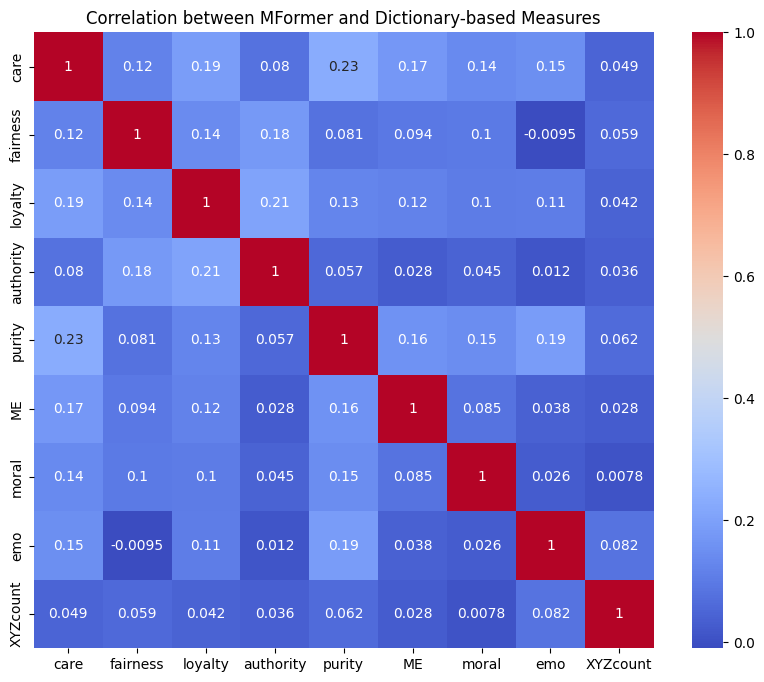

In [43]:
comparison_cols = ["care", "fairness", "loyalty", "authority", "purity"]
dictionary_cols = ["ME", "moral", "emo", "XYZcount"]

# Pearson correlation matrix
correlation = df_out[comparison_cols + dictionary_cols].corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation between MFormer and Dictionary-based Measures")
plt.show()

In [44]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---- MFormer Model: Continuous Scores ----
formula_mformer_cont = "diffusion ~ care + fairness + loyalty + authority + purity"
model_mformer_cont = smf.glm(formula=formula_mformer_cont, data=df_out, family=sm.families.NegativeBinomial()).fit()

# ---- MFormer Model: Binary Labels ----
formula_mformer_bin = "diffusion ~ care_binary + fairness_binary + loyalty_binary + authority_binary + purity_binary"
model_mformer_bin = smf.glm(formula=formula_mformer_bin, data=df_out, family=sm.families.NegativeBinomial()).fit()

# ---- Dictionary-Based Model ----
formula_dict = "diffusion ~ ME + emo + moral + XYZcount"
model_dict = smf.glm(formula=formula_dict, data=df_out, family=sm.families.NegativeBinomial()).fit()

# ---- Compare Models ----
print("\n--- MFormer (Continuous) Model ---")
print(model_mformer_cont.summary())

print("\n--- MFormer (Binary) Model ---")
print(model_mformer_bin.summary())

print("\n--- Dictionary-Based Model ---")
print(model_dict.summary())



--- MFormer (Continuous) Model ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:              diffusion   No. Observations:                 8026
Model:                            GLM   Df Residuals:                     8020
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -73201.
Date:                Sun, 06 Apr 2025   Deviance:                       5855.6
Time:                        13:42:59   Pearson chi2:                 1.83e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.008195
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [48]:
from google.colab import files
uploaded = files.upload()


Saving processed-data-mueller.csv to processed-data-mueller.csv


In [49]:
import pandas as pd

mueller = pd.read_csv("processed-data-mueller.csv", encoding="latin")

# Check the actual column names in your DataFrame
print(mueller.columns)



Index(['corpus', 'text', 'diffusion', 'followers', 'verified', 'media', 'urls',
       'hashtags', 'ME', 'moral', 'emo', 'charCount1', 'charCount2',
       'XYZcount', 'n_char'],
      dtype='object')


In [50]:
print(mueller.head())

           corpus                                               text  \
0  #MuellerReport  the latest sagebrush times thanks to geoengine...   
1  #MuellerReport  whats theemergenc shes waited 2 ears wh the ru...   
2  #MuellerReport  rejects muellerreport sas special counsel shou...   
3  #MuellerReport  i know whats in the muellerreport but im not g...   
4  #MuellerReport  i want reparations for all of m ta dollars tha...   

   diffusion  followers  verified  media  urls  hashtags  ME  moral  emo  \
0          3         10         0      0     1         1   0      0    1   
1          0       8926         0      0     1         1   0      0    0   
2       5166       2430         0      0     1         1   0      1    2   
3          0        341         0      0     0         1   0      0    2   
4       6309       1346         0      0     0         1   0      0    0   

   charCount1  charCount2  XYZcount  n_char  
0          65          65         0      65  
1          77     

In [51]:
from transformers import pipeline
import pandas as pd
from tqdm import tqdm

# Your cleaned text input
texts = mueller['text'].fillna("").tolist()

# Moral foundations and associated models
foundation_models = {
    "care": "joshnguyen/mformer-care",
    "fairness": "joshnguyen/mformer-fairness",
    "loyalty": "joshnguyen/mformer-loyalty",
    "authority": "joshnguyen/mformer-authority",
    "purity": "joshnguyen/mformer-sanctity"
}

# DataFrame to collect all predictions
preds_df = pd.DataFrame()

# Run each model separately
for foundation, model_name in foundation_models.items():
    print(f"Running model for: {foundation}")

    classifier = pipeline("text-classification", model=model_name, device=0 if torch.cuda.is_available() else -1)

    foundation_preds = []

    batch_size = 8
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]
        batch = [str(item) if not isinstance(item, str) else item for item in batch]

        results = classifier(batch)

        # Extract the score for the positive class
        scores = [r['score'] if r['label'] == 'LABEL_1' else 1 - r['score'] for r in results]
        foundation_preds.extend(scores)

    preds_df[foundation] = foundation_preds

# Merge predictions back into original DataFrame
df_out_mueller = pd.concat([df.reset_index(drop=True), preds_df.reset_index(drop=True)], axis=1)


Running model for: care


Device set to use cuda:0
100%|██████████| 4875/4875 [05:34<00:00, 14.58it/s]


Running model for: fairness


Device set to use cuda:0
100%|██████████| 4875/4875 [05:34<00:00, 14.58it/s]


Running model for: loyalty


Device set to use cuda:0
100%|██████████| 4875/4875 [05:34<00:00, 14.57it/s]


Running model for: authority


Device set to use cuda:0
100%|██████████| 4875/4875 [05:34<00:00, 14.56it/s]


Running model for: purity


Device set to use cuda:0
100%|██████████| 4875/4875 [05:32<00:00, 14.65it/s]


In [52]:
df_out_mueller = pd.concat([mueller.reset_index(drop=True), preds_df.reset_index(drop=True)], axis=1)


In [53]:
print(df_out_mueller.head())

           corpus                                               text  \
0  #MuellerReport  the latest sagebrush times thanks to geoengine...   
1  #MuellerReport  whats theemergenc shes waited 2 ears wh the ru...   
2  #MuellerReport  rejects muellerreport sas special counsel shou...   
3  #MuellerReport  i know whats in the muellerreport but im not g...   
4  #MuellerReport  i want reparations for all of m ta dollars tha...   

   diffusion  followers  verified  media  urls  hashtags  ME  moral  emo  \
0          3         10         0      0     1         1   0      0    1   
1          0       8926         0      0     1         1   0      0    0   
2       5166       2430         0      0     1         1   0      1    2   
3          0        341         0      0     0         1   0      0    2   
4       6309       1346         0      0     0         1   0      0    0   

   charCount1  charCount2  XYZcount  n_char      care  fairness   loyalty  \
0          65          65        

In [54]:
for col in ["care", "fairness", "loyalty", "authority", "purity"]:
    df_out_mueller[f"{col}_binary"] = df_out_mueller[col] > 0.5


In [55]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

nb_cols = ["diffusion", "care", "fairness", "loyalty", "authority", "purity"]
df_nb = df_out_mueller.dropna(subset=nb_cols)

formula_nb = "diffusion ~ care + fairness + loyalty + authority + purity"
model_nb = smf.glm(formula=formula_nb, data=df_nb, family=sm.families.NegativeBinomial()).fit()

print("\n--- Negative Binomial (MFormer continuous) ---")
print(model_nb.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



--- Negative Binomial (MFormer continuous) ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:              diffusion   No. Observations:                38998
Model:                            GLM   Df Residuals:                    38992
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4450e+05
Date:                Sun, 06 Apr 2025   Deviance:                   2.2850e+05
Time:                        14:24:51   Pearson chi2:                 1.32e+07
No. Iterations:                    28   Pseudo R-squ. (CS):             0.1330
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Inte

In [59]:
df_out_mueller["diffusion_binary"] = (df_out_mueller["diffusion"] > 5).astype(int)  # Convert to 0/1

In [60]:
logit_cols = ["diffusion_binary"] + [f"{col}_binary" for col in ["care", "fairness", "loyalty", "authority", "purity"]]
df_logit = df_out_mueller.dropna(subset=logit_cols)

formula_logit = "diffusion_binary ~ care_binary + fairness_binary + loyalty_binary + authority_binary + purity_binary"
model_logit = smf.logit(formula=formula_logit, data=df_logit).fit()

print("\n--- Logistic Regression (MFormer binary) ---")
print(model_logit.summary())


Optimization terminated successfully.
         Current function value: 0.309085
         Iterations 6


LinAlgError: Singular matrix

In [61]:
# Rename if needed to match your dataset
# e.g., if the column is actually "moral_words" instead of "moral"
dictionary_cols = ["diffusion", "ME", "emo", "moral", "XYZcount"]
df_dict = df_out_mueller.dropna(subset=dictionary_cols)

formula_dict = "diffusion ~ ME + emo + moral + XYZcount"
model_dict = smf.glm(formula=formula_dict, data=df_dict, family=sm.families.NegativeBinomial()).fit()

print("\n--- Negative Binomial (Dictionary-based) ---")
print(model_dict.summary())



--- Negative Binomial (Dictionary-based) ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:              diffusion   No. Observations:                38998
Model:                            GLM   Df Residuals:                    38993
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4593e+05
Date:                Sun, 06 Apr 2025   Deviance:                   2.3136e+05
Time:                        14:26:55   Pearson chi2:                 1.33e+07
No. Iterations:                    16   Pseudo R-squ. (CS):            0.06703
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [63]:
print("\nModel Comparison (AIC):")
print(f"MFormer (NB, continuous): {model_nb.aic:.2f}")
print(f"Dictionary (NB):          {model_dict.aic:.2f}")



Model Comparison (AIC):
MFormer (NB, continuous): 289004.16
Dictionary (NB):          291860.23
